In [1]:
import sys

# Se importa desde GitHub funciones.py si se está corriendo desde Colab

if 'google.colab' in sys.modules:

    !wget -O funciones.py \
    https://github.com/francobarrionuevoenv21/MAIE_devs_pub/raw/refs/heads/main/Proc_Img/practicos/backup%20pys/funciones.py



--2026-08-04 14:35:21--  https://github.com/francobarrionuevoenv21/MAIE_devs_pub/raw/refs/heads/main/Proc_Img/practicos/backup%20pys/funciones.py
Resolving github.com (github.com)... 140.82.116.3
Connecting to github.com (github.com)|140.82.116.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/francobarrionuevoenv21/MAIE_devs_pub/refs/heads/main/Proc_Img/practicos/backup%20pys/funciones.py [following]
--2026-08-04 14:35:21--  https://raw.githubusercontent.com/francobarrionuevoenv21/MAIE_devs_pub/refs/heads/main/Proc_Img/practicos/backup%20pys/funciones.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2801 (2.7K) [text/plain]
Saving to: ‘funciones.py’

funciones.py        100%[================

In [2]:
# Librerías

## Librerías generales
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import rasterio
from rasterio.crs import CRS
from rasterio.mask import mask
import os

# Import funciones.py
import funciones as fn

## Librerías para abrir imágenes desde GitHub como numpy arrays
import requests
import matplotlib.image as mpimg
from PIL import Image
from io import BytesIO

# Clase 01 - Operaciones básicas con imágenes y datos

**Funciones**

In [2]:
# Defino una función que toma una imagen como array de numpy y la ecualiza según el valor de percentil (p) definido
def scale(imagen, p):

    # Obtengo los valores de los percentiles p y 100-p
    vmin = np.percentile(imagen, p)
    vmax = np.percentile(imagen, 100-p)

    # Trunco la imagen con numpy.clip()
    img_trun = np.clip(imagen, vmin, vmax)  # Limitar los valores a este rango
    
    # Normalizar a 0-255
    img_ecual = (img_trun - vmin) / (vmax - vmin) * 255 # Si sacamos este *255 queda escalada de 0 a 1

    # Convertir la imagen ecualizada a entero de 8 bits (ya que la normalizamos y escalamos de 0 a 255)
    img_ecual = np.uint8(img_ecual)

    return img_ecual

### <h3 style="color:red;">Ejercicio 1.1. - Solución</h3>

Descargá la imagen [recorte_trinidad.tif](https://drive.google.com/file/d/18dwsDDxltjQbQKsWDc9kqqGMxNFdPmjh/view?usp=drive_link), que corresponde a una adquisición Sentinel-1 (radar) de Trinidad y Tobago. Leela con `mpimg.imread()` y visualizala junto a su histograma, aplicando contraste visual jugando con los valores `vmin` y `vmax`. Explicá en una celda de texto cómo elegiste esos valores y cuáles son.

In [3]:
# Recupero la imagen desde github
trin_path = 'https://github.com/francobarrionuevoenv21/MAIE_devs_pub/raw/refs/heads/main/Proc_Img/practicos/data/recorte_trinidad_int.tif'

# Leo la imagen con `mpimg.imread()`
## Descargo la imagen con response
response = requests.get(trin_path)
response.raise_for_status()  # evanta un error si no puede descargar la imagen

## Leo la imagen con bytesIO
imagen_trin = mpimg.imread(BytesIO(response.content), format="tif") # BytesIO creates a file-like object from the downloaded bytes, so the image can be read without first saving it to disk

In [4]:
# Visualizo tipo de datos
print(f"Tipo de datos: {imagen_trin.dtype}")

# Visualizo dimensiones matriz
print(f"Dimensiones matriz: {imagen_trin.shape}")
# Defino percentil (P) para evaluación de valores en la imagen
P = 1

# Visualizo máx y min
print(f"Array min: {imagen_trin.min()}. Array max: {imagen_trin.max()}")

# Visualizo p:p y p: 100-P
print(f"Array p{P}: {np.nanpercentile(imagen_trin, 5):.3f}. Array p{100-P}: {np.nanpercentile(imagen_trin, 100-P):.3f}")

# Visualizo media y desvío estándar
print(f"Array media: {imagen_trin.mean()}. Array DE: {imagen_trin.std()}")

Tipo de datos: uint16
Dimensiones matriz: (1129, 1622)
Array min: 22. Array max: 65512
Array p1: 906.000. Array p99: 7003.000
Array media: 2106.7285759688257. Array DE: 1859.4542078988602


Text(0.5, 1.0, 'Histograma Original')

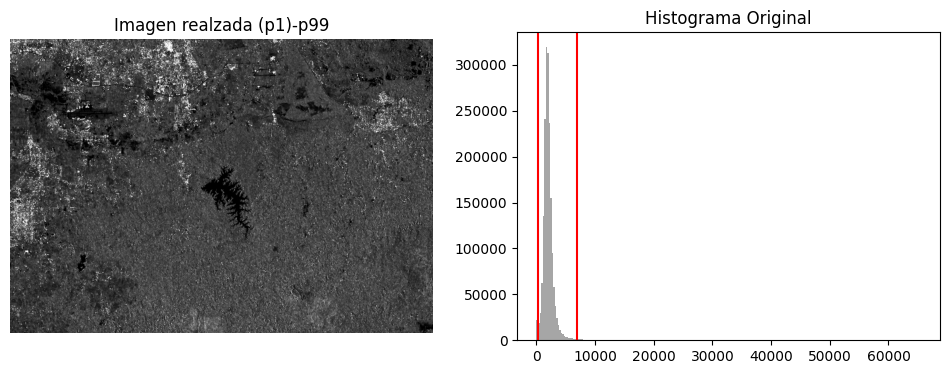

In [ ]:
# Ploteo la escena de S1 y el histograma de los valores
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Defino vmin y vmax para visualización según percentil (P)
vmin = np.nanpercentile(imagen_trin, P)
vmax = np.nanpercentile(imagen_trin, 100-P)

# Visualización imagen e histograma
axes[0].imshow(imagen_trin, cmap='gray',
    vmin = vmin, 
    vmax = vmax)
axes[0].set_title(f'Imagen realzada (p{P}-p{100-P})')
axes[0].axis('off')

axes[1].hist(imagen_trin.ravel(), bins=255, color='gray', alpha=0.7)
axes[1].axvline(np.nanpercentile(imagen_trin, P), color='red')
axes[1].axvline(np.nanpercentile(imagen_trin, 100-P), color='red')
axes[1].set_title('Histograma Original')


**Respuesta**

Para el realce de la visualización de la imagen se han empleado los percentiles 5 y 95, como valores míimo y máximo respectivamente. 

### <h3 style="color:red;">Ejercicio 1.2. - Solución</h3>

Una vez que tengas implemetada tu nueva función `scale`, aplicala sobre cualquier imagen de **una sola banda o canal** que tengas disponible. La podés leer con `mpimg.imread()`, y en lo posible evitá trabajar con imágenes de color o multicanal, ya que sobre eso nos centraremos en la Clase 03.

Creá visualizaciones con `Matplotlib` que permitan visualizar la imagen original junto a la imagen estirada, junto a sus respectivos histogramas.

In [14]:
# Recupero la imagen desde github
esr_path = 'https://github.com/francobarrionuevoenv21/MAIE_devs_pub/raw/refs/heads/main/Proc_Img/practicos/data/l8swir_esr_20170222.tif' # Recorte de escena banda SWIR de Landsat 8 sobre el Embalse San Roque el día 22/02/2017

## Descargo la imagen con response
response = requests.get(esr_path)
response.raise_for_status()  # levanta un error si no puede descargar la imagen

## Leo la imagen con bytesIO
imagen_esr = mpimg.imread(BytesIO(response.content), format="tif") # BytesIO creates a file-like object from the downloaded bytes, so the image can be read without first saving it to disk

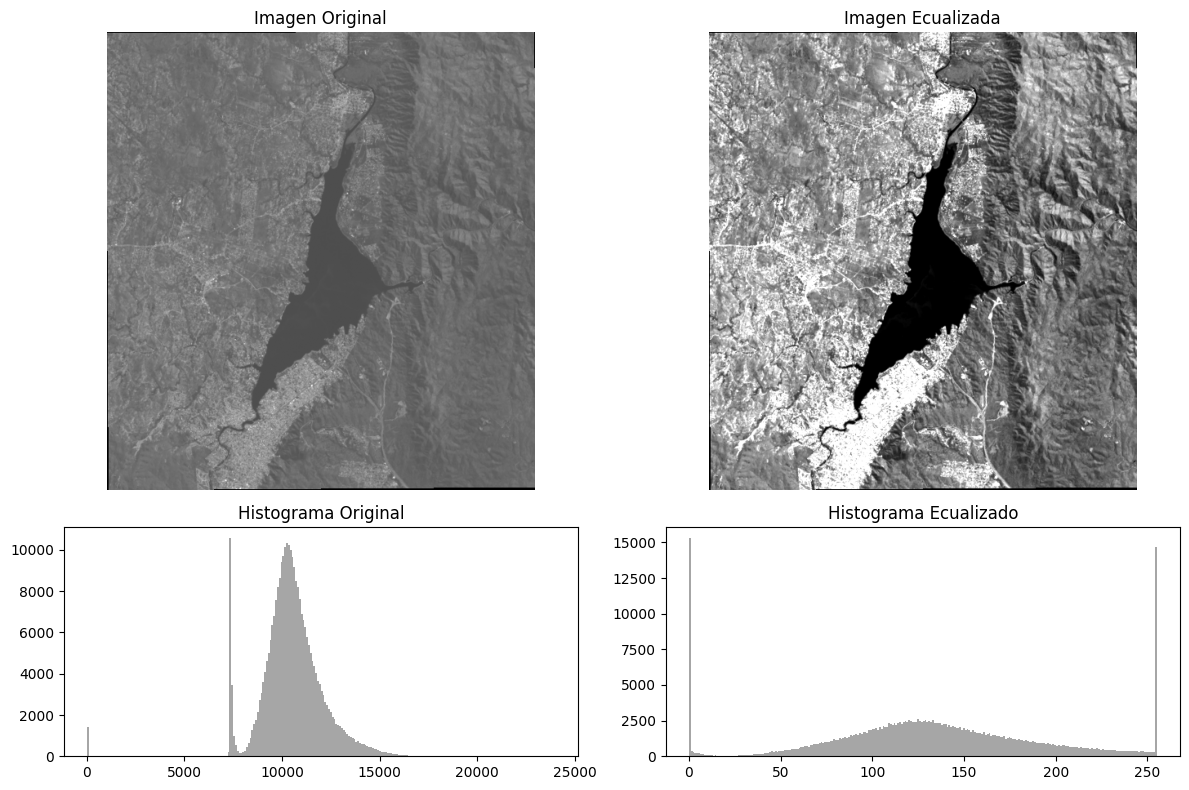

In [14]:
# Crear una figura con 2 filas: imágenes e histogramas originales y escalados
fig, axes = plt.subplots(2, 2, figsize=(12, 8), gridspec_kw={"height_ratios": [2, 1]})

# Defino percentil (P) para estiramiento
P = 5

# ---------------------- IMÁGENES ----------------------
axes[0, 0].imshow(imagen_esr, cmap='gray')
axes[0, 0].set_title('Imagen Original')
axes[0, 0].axis('off')

axes[0, 1].imshow(scale(imagen_esr, P), cmap='gray')
axes[0, 1].set_title('Imagen Ecualizada')
axes[0, 1].axis('off')

# ---------------------- HISTOGRAMAS ----------------------
# Histograma de la imagen original
axes[1, 0].hist(imagen_esr.ravel(), bins=256, color='gray', alpha=0.7)
axes[1, 0].set_title('Histograma Original')

# Histograma de la imagen ecualizada
axes[1, 1].hist(scale(imagen_esr, P).ravel(), bins=256, color='gray', alpha=0.7)
axes[1, 1].set_title('Histograma Ecualizado')

# Ajustar el diseño
plt.tight_layout()
plt.show()

# Clase 02 - Manipulación de imágenes satelitales con Rasterio

### Ejercicio 3.1.-Respuesta

Buscá una escena satelital cualquiera (solo una de sus bandas), donde tengas zonas de píxeles sin datos. Un ejemplo puede ser Landsat 8/9, que típicamente tiene píxeles con valores sin dato. En este caso ya podés abrirla directamente con `Rasterio`

Abrí esa banda saelital con Python, identificá cuál es el valor de `nodata`, y usalo en la función `scale` para visualizar la banda con mejor contraste.

In [2]:
# Leo y obtengo los datos de la banda 7 una escena de Landsat 8 de Córdoba
#l8_b7_path = 'https://github.com/francobarrionuevoenv21/MAIE_devs_pub/raw/refs/heads/main/Teledt_ambiental/TP2_Clorofila-a/L8/LC08_L2SP_229082_20170222_20200905_02_T1_SR_B7.TIF'
l8_b7_path = os.path.join('data/LC08_L2SP_229082_20170222_20200905_02_T1_SR_B7.TIF')
l8_b7_ds = rasterio.open(l8_b7_path)
l8_b7_da = l8_b7_ds.read()

In [4]:
# Printeo el shape
print(f'Shape: {l8_b7_da.shape}')

# Obtengo valor nodata en el raster
l8_b7_nodata = l8_b7_ds.nodata
print(f'Valor nodata: {l8_b7_nodata}')

Shape: (1, 7741, 7681)
Valor nodata: 0.0


NameError: name 'l8_b7_da' is not defined

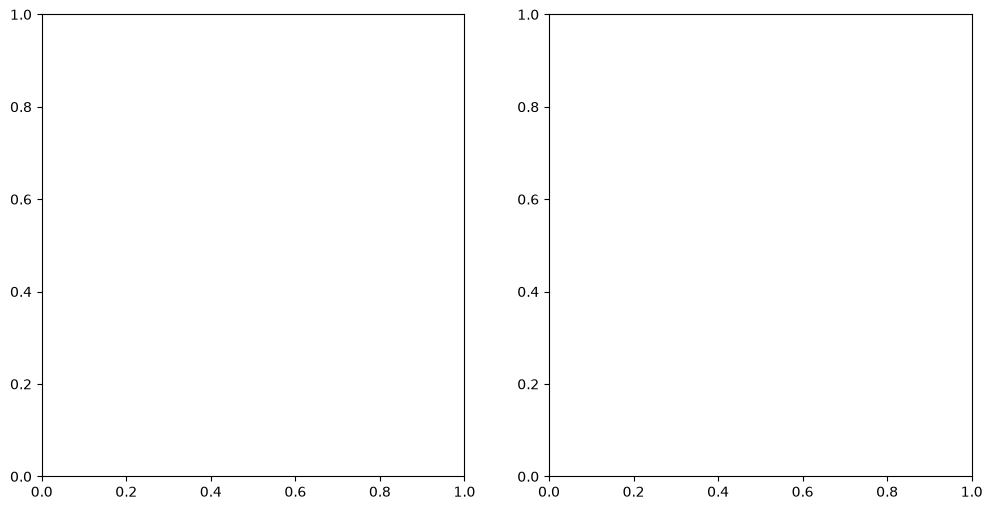

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(l8_b7_da[0], cmap='gray')
ax[0].set_title('Imagen Original')
ax[0].axis('off')

ax[1].imshow(fp.scale(l8_b7_da[0], 5, l8_b7_nodata), cmap='gray')
ax[1].set_title('Imagen Ecualizada')
ax[1].axis('off')

### Ejercicio 3.2.-Respuesta

Sobre la escena del ejercicio anterior, definí una esquina superior izquierda (`ulx,uly`) y una esquina inferior derecha (`lrx,lry`), y extraé el recángulo definido por sus coordenadas replicando el ejercicio 2.1, o utilizando la función `subset_img` del ejercicio 3.4 si ya la tenés implementada. Ploteá el recorte extraído usando `imshow`.

In [9]:
ul_x, ul_y = 352780,-3461018
lr_x, lr_y = 365815,-3485242

subset_esr, window = fp.subset_img(l8_b7_ds, [1], ul_x, ul_y, lr_x, lr_y)

(np.float64(-0.5), np.float64(433.5), np.float64(806.5), np.float64(-0.5))

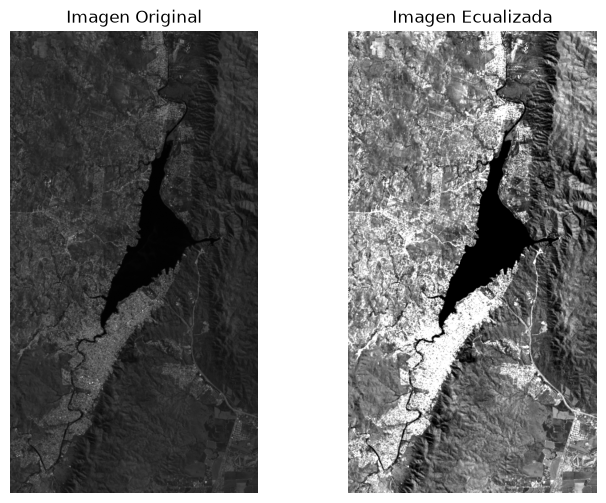

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(8, 6))

ax[0].imshow(subset_esr, cmap='gray')
ax[0].set_title('Imagen Original')
ax[0].axis('off')

subset_nodata = l8_b7_ds.nodata
ax[1].imshow(fp.scale(subset_esr, 5, subset_nodata), cmap='gray')
ax[1].set_title('Imagen Ecualizada')
ax[1].axis('off')

### Ejercicio 3.3.-Respuesta

Descargá el siguiente [archivo Geotiff](https://drive.google.com/file/d/1dIuD4Wa-hXH43iz5Fx5NaMi1hxHlwD4U/view?usp=sharing) que contiene un mapa de NDWI realizado a partir de una imagen SPOT. Leelo con `Rasterio`, visualizá los datos (la imagen, el histograma), y determiná un umbral que te ayude a binarizar la imagen y distinguir Agua de No-Agua, aplicando la lógica que utilizamos en la clase 01 sobre la imagen de Homero (la que pasamos a 0-1). Luego, ayudate del `transform` de la imagen para determinar qué superficie tiene cada clase, como en el ejercicio de la sección 2.2.

In [5]:
#spot_ndwi_path = ''
spot_ndwi_path = os.path.join('data', 'spot_apilada_ndwi.tif')
spot_ndwi_ds = rasterio.open(spot_ndwi_path)
spot_ndwi_da = spot_ndwi_ds.read()[0]

Text(0.5, 1.0, 'Histograma Ecualizado')

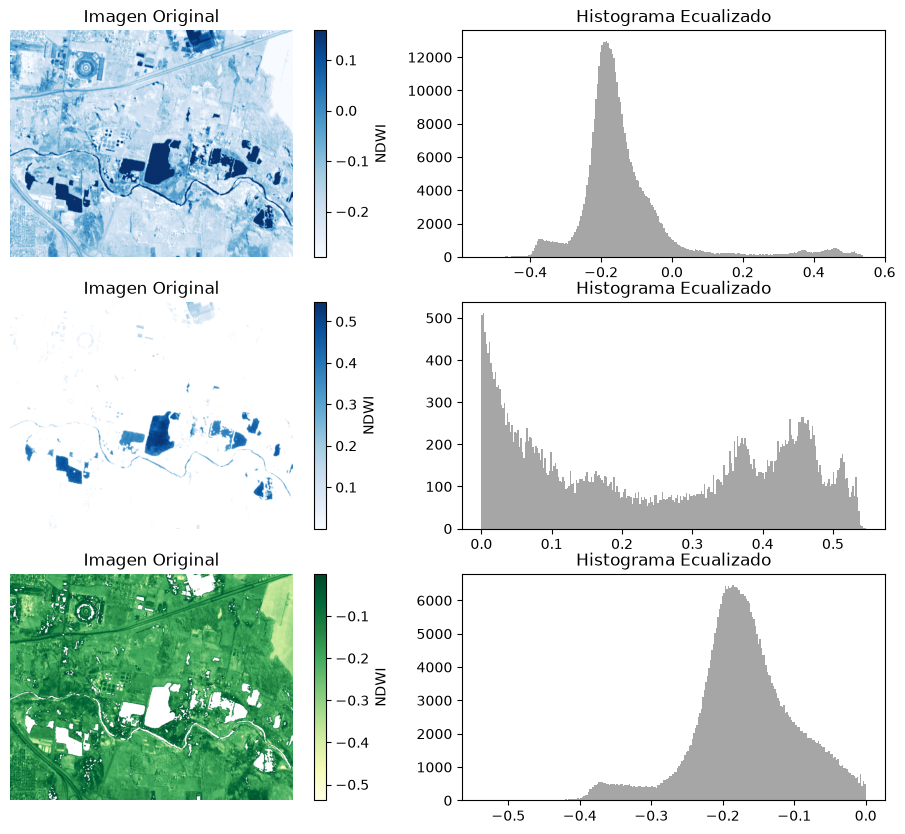

In [32]:
fig, ax = plt.subplots(3, 2, figsize=(12, 10))

im1 =  ax[0, 0].imshow(spot_ndwi_da, 
                vmin = np.nanpercentile(spot_ndwi_da, 5),
                vmax = np.nanpercentile(spot_ndwi_da, 100-5),
                cmap='Blues')
ax[0, 0].set_title('Imagen Original')
ax[0, 0].axis('off')

fig.colorbar(
    im1,
    label="NDWI"
)


ax[0, 1].hist(spot_ndwi_da.ravel(), bins=256, color='gray', alpha=0.7)
ax[0, 1].set_title('Histograma Ecualizado')

# ---

# Defino NDWI threshold

thresh = 0

im2 = ax[1, 0].imshow(np.where(spot_ndwi_da>0, spot_ndwi_da, np.nan), cmap='Blues')
ax[1, 0].set_title('Imagen Original')
ax[1, 0].axis('off')

fig.colorbar(
    im2,
    label="NDWI"
)

ax[1, 1].hist(np.where(spot_ndwi_da>0, spot_ndwi_da, np.nan).ravel(), 
              bins=256, color='gray', alpha=0.7)
ax[1, 1].set_title('Histograma Ecualizado')

im3 = ax[2, 0].imshow(np.where(spot_ndwi_da<0, spot_ndwi_da, np.nan), cmap='YlGn')
ax[2, 0].set_title('Imagen Original')
ax[2, 0].axis('off')

fig.colorbar(
    im3,
    label="NDWI"
)

ax[2, 1].hist(np.where(spot_ndwi_da<0, spot_ndwi_da, np.nan).ravel(), 
              bins=256, color='gray', alpha=0.7)
ax[2, 1].set_title('Histograma Ecualizado')

In [19]:
ds_transform = spot_ndwi_ds.transform

area_px = ds_transform.a * ds_transform.e * (-1) 

area_agua = np.sum(spot_ndwi_da > 0 * 1) * area_px / 10000
area_Noagua = np.sum(spot_ndwi_da < 0 * 1) * area_px / 10000

print(f'Área cubierta por agua [ha]: {area_agua}')
print(f'Área cubierta por no-agua [ha]: {area_Noagua}')

Área cubierta por agua [ha]: 136.9764
Área cubierta por no-agua [ha]: 1483.0236


### Ejercicio 3.4.-Respuesta

Defina una función que genere un recorte a partir de unas coordenadas y una imagen suministrada y que además devuelva la ventana utilizada para hacer ese recorte.

In [ ]:
# Función implementada y accesible desde funcion.py
help(fn.subset_img)

Help on function subset_img in module funciones:

subset_img(ds, ul_x, ul_y, lr_x, lr_y, bands_list=[1])
    Parámetros:
    ds: Rasterio dataset;
    ul_x: Coordenada x del extremo superior izquierdo;
    ul_y: Coordenada y del extremo superior izquierdo;
    lr_x: Coordenada x del extremo inferior derecho;
    lr_y: Coordenada y del extremo inferior derecho;
    bands_list: Lista de bandas a seleccionar. Si es singleband: [1] (Default);
    ---
    Return
    subset: dataarray recortado según las coordenadas indicadas;
    window: Elemento Window de rasterio según las coordenadas indicadas



# Clase 03 - Visualización RGB y operaciones elementales sobre Rasters

### Ejercicio 3.1. - Respuesta

Elegí un umbral para binarizar la imagen de NDWI calculada en el ejercicio 2.1 (podés repetir el que usaste para la Clase 02) y diferenciar Agua de No-Agua, aplicando la misma lógica que usamos sobre la imagen de Homero en la Clase 01. Guardá esa máscara como un archivo GeoTiff en `output`, reutilizando los metadatos de la imagen original como ayuda.

In [ ]:
#--
spot_multibanda = rasterio.open('https://github.com/francobarrionuevoenv21/MAIE_devs_pub/raw/refs/heads/main/Proc_Img/practicos/data/SPOT_20170806_MS_p.tif')

# --
dict_meta = spot_multibanda.meta
print('Printeo metadatos archivo .tif')
dict_meta

Printeo metadatos archivo .tif


{'driver': 'GTiff',
 'dtype': 'float32',
 'nodata': None,
 'width': 1801,
 'height': 989,
 'count': 4,
 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 20S",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-63],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32720"]]'),
 'transform': Affine(6.0, 0.0, 388866.0,
        0.0, -6.0, 6528056.0)}

In [4]:
# --
ulx, uly = 393360.0, 6526862.0
lrx, lry = 397860.0, 6523262.0

spot_apilada, ventana_recorte = fn.subset_img(spot_multibanda, ulx, uly, lrx, lry, [1, 2, 3, 4])

In [22]:
b_nir = spot_apilada[3].astype(np.float32)
b_green = spot_apilada[1].astype(np.float32)

ndwi = (b_green - b_nir) / (b_green + b_nir)
ndwi_thr = 0.1
ndwi_agua = np.where(ndwi > ndwi_thr, 1, np.nan)

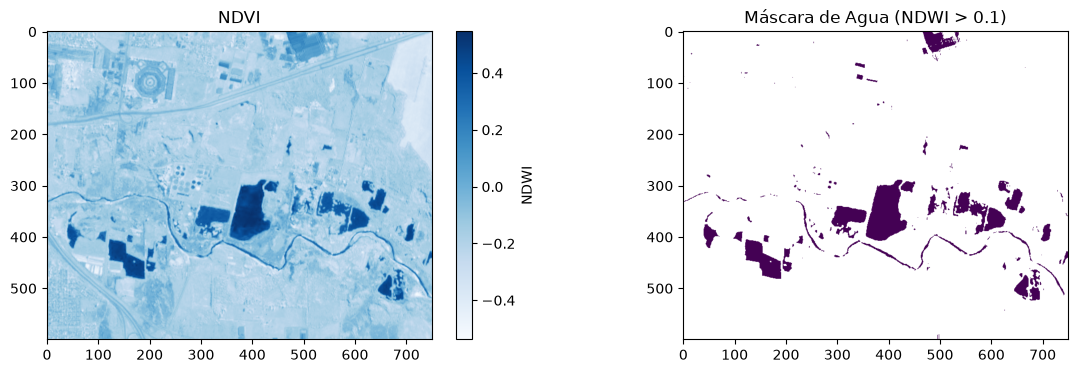

In [23]:
fig,ax = plt.subplots(1, 2, figsize = (14, 4))


im1 = ax[0].imshow(ndwi, cmap = 'Blues')
ax[0].set_title("NDVI")

fig.colorbar(
    im1,
    label="NDWI"
)

ax[1].imshow(ndwi_agua)
ax[1].set_title(f'Máscara de Agua (NDWI > {ndwi_thr })')

plt.show()

In [ ]:
# --
bandas = 1

transform_updt = rasterio.windows.transform(ventana_recorte, spot_multibanda.transform)

recorte_metadatos = {'driver': dict_meta['driver'],
                  'dtype': dict_meta['dtype'],
                  'nodata': dict_meta['nodata'],
                  'width': spot_apilada.shape[2],
                  'height': spot_apilada.shape[1],
                  'count': bandas,
                  'crs': dict_meta['crs'],
                  'transform': transform_updt}

In [ ]:
with rasterio.open(
    "output/img_spot_aguaMask", "w",**recorte_metadatos) as dst:
    dst.write(ndwi_agua, 1)   # escribir en la banda 1
    dst.set_band_description(1, "Agua")

### Ejercicio 3.2. - Resolución

Buscá una escena satelital óptica distinta a las que trabajamos en esta Notebook que contenga las bandas necesarias para calcular un índice espectral de tu interés. Puede ser un archivo GeoTiff ya procesado previamente por vos en otro curso, no tiene que ser una imagen satelital cruda. También podés abrir las bandas por separado, si vienen así. Definí un par de coordenadas de interés para extraer un recorte, calculá el índice correspondiente sobre ese recorte, y guardá el archivo como GeoTiff. También podés guardar las bandas que utilizaste para computarlo. Incluí las descripciones de bandas correspondientes y asegúrate de que la geolocalización de la imagen de salida sea correcta.

Por último, incluí visualizaciones en RGB combinando las distintas bandas disponibles, aprovechando la función `scale_multiband` que desarrollamos en el ejercicio 1.2. Si las bandas vienen como archivos separados, utilizá `np.array()` u otra similar, para apilarlas.

In [6]:
#  --
list_l8Bans_paths = ['https://github.com/francobarrionuevoenv21/MAIE_devs_pub/raw/refs/heads/main/Teledt_ambiental/TP2_Clorofila-a/L8/LC08_L2SP_229082_20170222_20200905_02_T1_SR_B2.TIF',
'https://github.com/francobarrionuevoenv21/MAIE_devs_pub/raw/refs/heads/main/Teledt_ambiental/TP2_Clorofila-a/L8/LC08_L2SP_229082_20170222_20200905_02_T1_SR_B3.TIF',
'https://github.com/francobarrionuevoenv21/MAIE_devs_pub/raw/refs/heads/main/Teledt_ambiental/TP2_Clorofila-a/L8/LC08_L2SP_229082_20170222_20200905_02_T1_SR_B4.TIF']

In [ ]:
# --
ulx, uly = 370537, -3515903
lrx, lry = 384057,-3525716

# --
dict_bands = {} # Creo un diccionario para subset de bandas + ventanas + nodata
bands_keys = ['Blue', 'Green', 'Red']

# --
for i, p in enumerate(list_l8Bans_paths):

    #print(i, p, bands_keys[i])
    band_ds = rasterio.open(p)
    subset, window = fn.subset_img(band_ds, ulx, uly, lrx, lry) # Imagen singleband

    dict_bands[bands_keys[i]] = {'subset' : subset,
                                'window' : window,
                                'no_data': band_ds.nodata}

In [29]:
# --
arrays = []

for i in range(len(list_l8Bans_paths)):
    #print(i)
    arrays.append(dict_bands[bands_keys[i]]['subset'][0])

stack_imgs = np.stack(arrays)

In [37]:
# --
no_data = dict_bands[bands_keys[0]]['no_data']

# --
stackImgs_scaled = fn.scale_multiband(stack_imgs, p = 1, nodata = no_data)

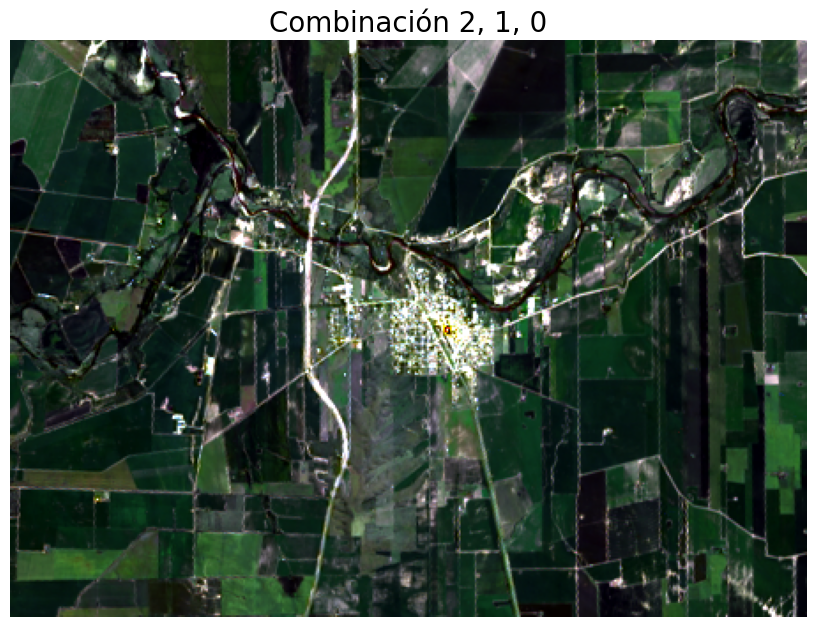

In [ ]:
# -- 
r = 2
g = 1
b = 0

fig, ax = plt.subplots(figsize=(15, 7.5))
ax.set_title(f'Combinación {r}, {g}, {b}', size=20)
ax.imshow(stackImgs_scaled[[r, g, b]].transpose(1,2,0))
ax.axis("off")
plt.show()

# Clase 04 - Datos Vectoriales y Geopandas

### <h3 style="color:red;">Ejercicio 2.2. - Resolución</h3>

a) Probar qué sucede con el tamaño y extensión espacial de los archivos guardados como GeoTiff cuando en el comando Mask se configura el parámetro **crop** como `False`. Buscar en la documentación de Rasterio a qué se refiere este parámetro.

In [ ]:

radios = gpd.read_file('data/radios_recorte_cordoba/radios_recorte_cordoba.shp')

s2 = rasterio.open('data/S2_20180619_2-3-4-8-11-12.tif')
#s2_bandas = s2.read()

radios_32720 = radios.to_crs(s2.crs) # s2.crs.to_authority()

poligono = radios_32720.loc[radios['link'] == '140140710'].copy()
#poligono.plot()

In [ ]:
s2_mask_ct, mask_transform = mask(dataset=s2,shapes = poligono.geometry, crop = True)
s2_mask_cf, mask_transform = mask(dataset=s2,shapes = poligono.geometry, crop = False)

# NOTA: recordar que mask asigna como 0 a los Nan values

In [10]:
s2_mask_ct.shape, s2_mask_cf.shape

((6, 409, 287), (6, 594, 1081))

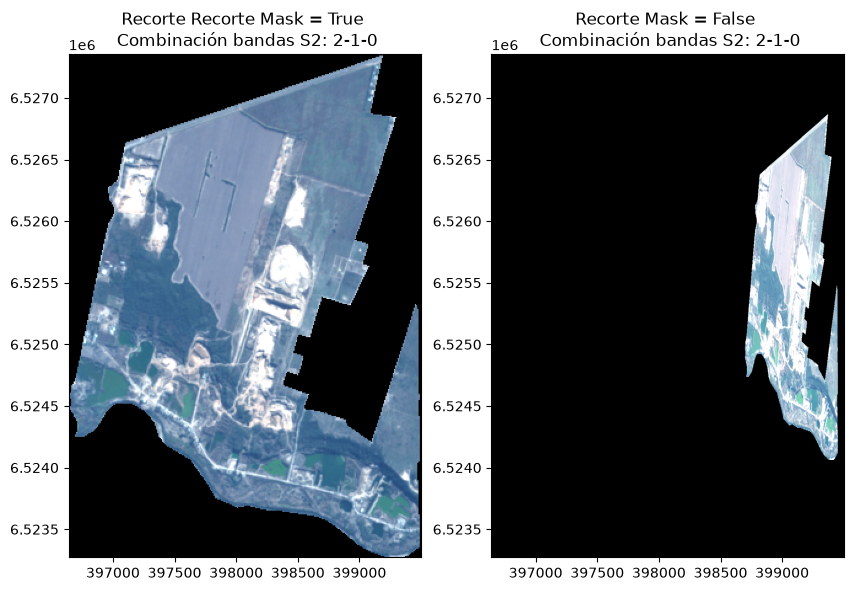

In [44]:
minx, miny, maxx, maxy = poligono.total_bounds
plot_extent = (minx, maxx, miny, maxy)
#rgb_clip = fn.scale_multiband(s2_clip, p=2)

fig, ax = plt.subplots(1, 2, figsize = (10,10))

## --
ax[0].imshow(fn.scale_multiband(s2_mask_ct, 2, 0)[[2,1,0]].transpose(1,2,0), extent = plot_extent)
ax[0].set_title("Recorte Recorte Mask = True \n Combinación bandas S2: 2-1-0")

## --
ax[1].imshow(fn.scale_multiband(s2_mask_cf, 2, 0)[[2,1,0]].transpose(1,2,0), extent = plot_extent)
ax[1].set_title("Recorte Mask = False \n Combinación bandas S2: 2-1-0")

plt.show()

<h3 style="color:red;">Ejercicio 2.3. - Entregable!</h3>

Buscá la misma escena satelital que procesaste para el ejercicio 2.4 de la Clase 03, ya sea la imagen original o los índices / bandas que generaste luego de hacer esa actividad. Buscá o creá (no tenés que hacerlo en Python, puede ser con las herramientas de SIG que ya uses) un polígono vectorial que te sirva para extraer un sector de esa imagen usando el `mask` de Rasterio. Guardá el nuevo recorte generado definiendo de manera consistente los píxeles con valores sin datos, en caso de corresponder.

In [17]:
l8_b7_path = 'https://github.com/francobarrionuevoenv21/MAIE_devs_pub/raw/refs/heads/main/Teledt_ambiental/TP2_Clorofila-a/L8/LC08_L2SP_229082_20170222_20200905_02_T1_SR_B7.TIF'
#l8_b7_path = os.path.join('data/LC08_L2SP_229082_20170222_20200905_02_T1_SR_B7.TIF')
l8_b7_ds = rasterio.open(l8_b7_path)
l8_b7_da = l8_b7_ds.read()

In [20]:
esr_path = 'https://github.com/francobarrionuevoenv21/MAIE_devs_pub/raw/refs/heads/main/Teledt_ambiental/TP2_Clorofila-a/output/lago_mndwi'
gdf_esr = gpd.read_file(esr_path)

In [24]:
esr_32620 = gdf_esr.to_crs(l8_b7_ds.crs)

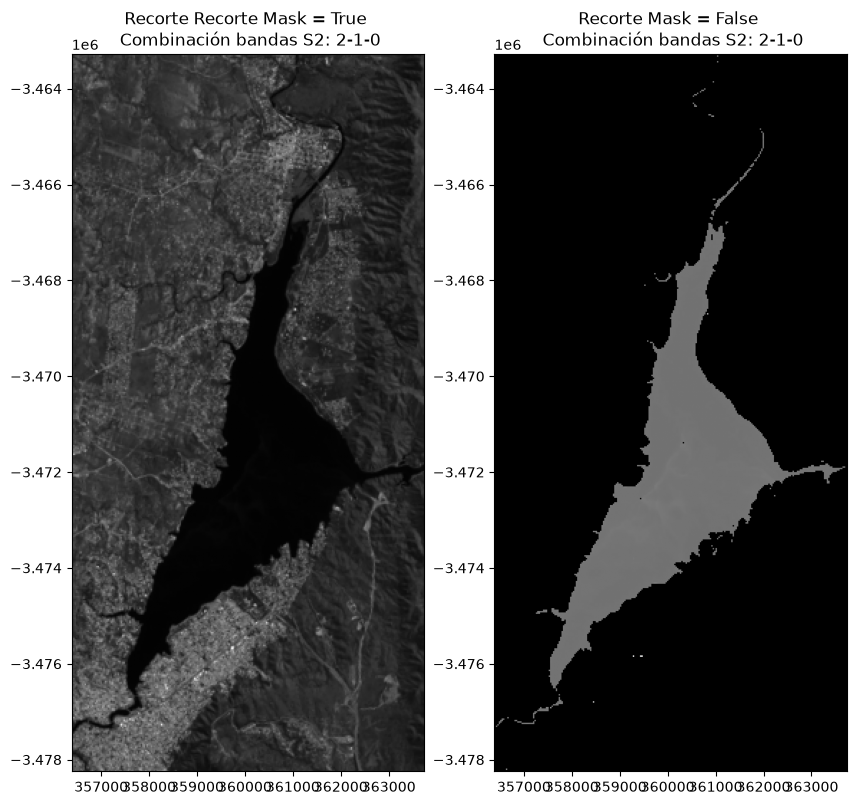

In [43]:
minx, miny, maxx, maxy = esr_32620.total_bounds
plot_extent = (minx, maxx, miny, maxy)
#rgb_clip = fn.scale_multiband(s2_clip, p=2)

fig, ax = plt.subplots(1, 2, figsize = (10,10))

## --
ax[0].imshow(fn.subset_img(l8_b7_ds, minx, maxy, maxx, miny)[0][0], # ul_x, ul_y, lr_x, lr_y
cmap='gray', extent = plot_extent)
ax[0].set_title("Recorte Recorte Mask = True \n Combinación bandas S2: 2-1-0")

## --
l8_b7_mask, mask_transform = mask(dataset=l8_b7_ds, shapes = esr_32620.geometry, crop = True)
ax[1].imshow(l8_b7_mask[0], cmap='gray', extent = plot_extent)
ax[1].set_title("Recorte Mask = False \n Combinación bandas S2: 2-1-0")

plt.show()